<a href="https://colab.research.google.com/github/somendrew/LangGraph_tutorial/blob/main/4_First_Simple_Graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## THE PLAN

We're going to build a Customer Support Bot that:

* Takes a user message
* Classifies the intent
* Generates a reply
* Formats it with a sign-off



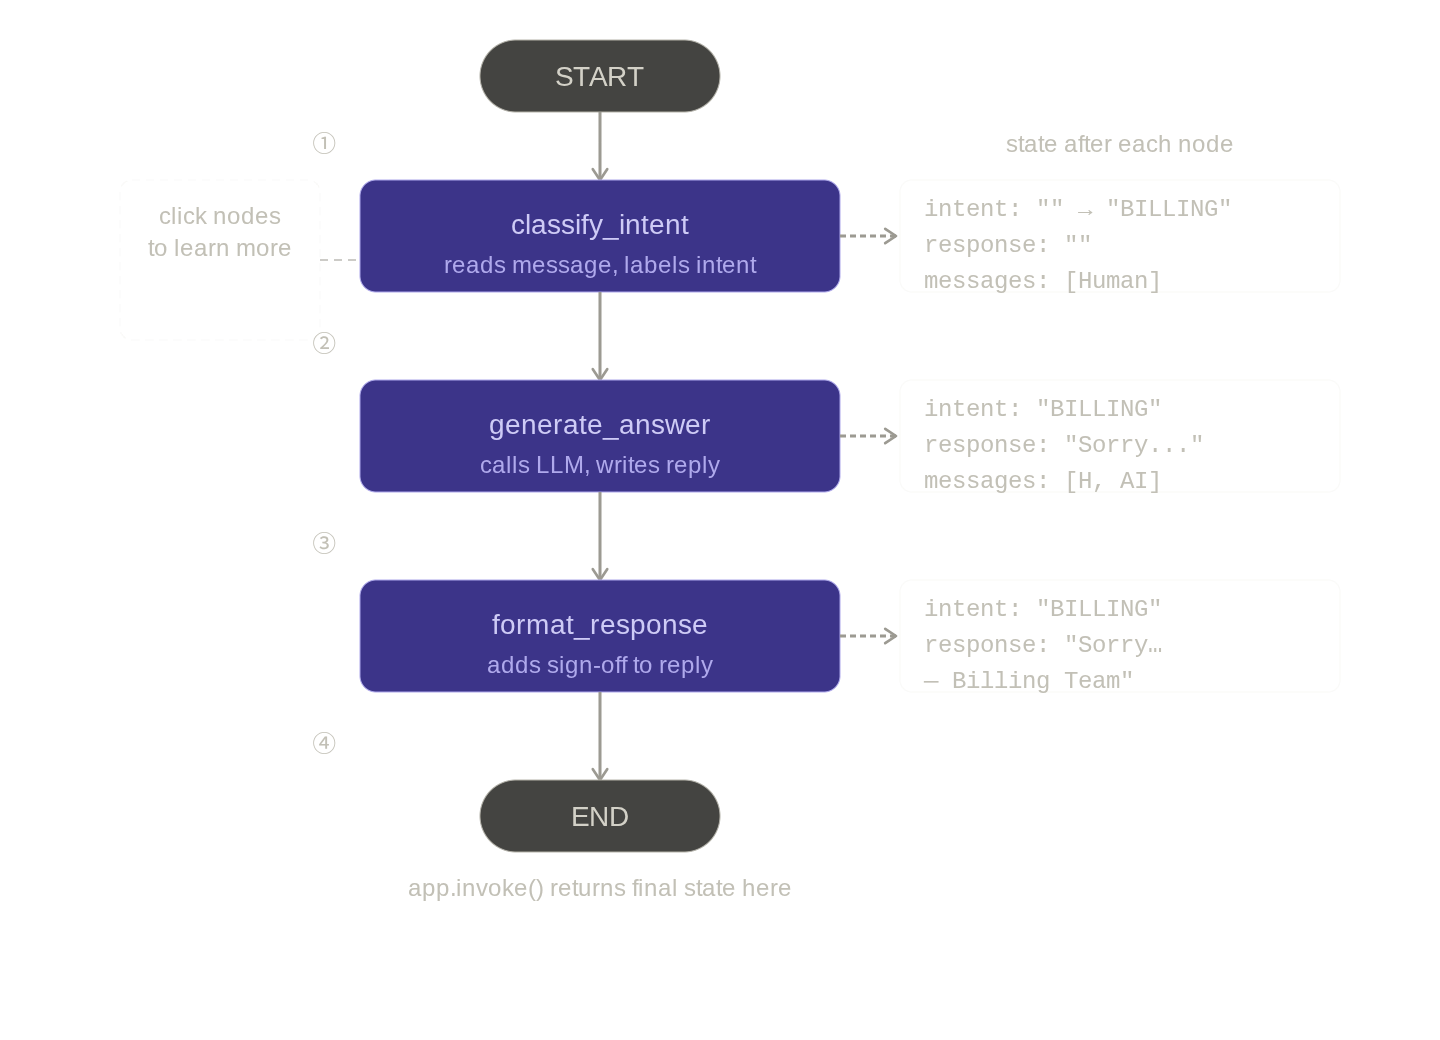

## Installing libraries

In [1]:
!pip install -q langchain_openai typing langgraph langchain_core

## Setting up API

In [2]:
from google.colab import userdata
api_key = userdata.get('api_key')

## Execution

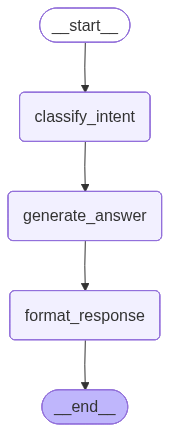

In [12]:
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated
from langgraph.graph import START, StateGraph, END
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.graph.message import add_messages


llm = ChatOpenAI(model = "gpt-4o-mini",api_key = api_key)
###############################################################
# Creating STATE
###############################################################
class SupportState(TypedDict):
  user_message : str
  intent : str
  response : str

  #messages that contains all the context
  messages : Annotated[list,add_messages]

###############################################################
#Creating node function
###############################################################
def classify_intent(state:SupportState) -> dict:
  """NODE 1: Classify the message into one of the 3 categories"""

  prompt = f"""
  You're a classifier. Read the message and classify the message into one of the following :
  1. BILLING
  2. TECHNICAL
  3. GENERAL

  MESSAGE :{state['user_message']} """

  result = llm.invoke(prompt)
  intent = result.content.strip().upper()
  print(f"  [NODE 1], Intent : {intent}")
  return {'intent': intent}

def generate_answer(state:SupportState) -> dict:
  """NODE 2: Generate the helpful reply using intent + message history"""
  prompt = f"""
  - You're an Customer Support Agent.
  - Customer message type is : {state['intent']}
  - Keep the message short and simple
  """

  #build a msg list, system instructions + full history
  messages =[
      {"role":"system","content":prompt},
      {"role":"user","content":state["user_message"]}
  ]

  result = llm.invoke(messages)
  print("  [Node 2] generated reply")
  return {
      "response":result.content,
       #add message, reducer will apend this to the list
      "messages":[AIMessage(content = result.content)]
  }

def format_response(state:SupportState) ->dict:
  """Node 3: polish the reply with a team sign-off."""
  sign_offs = {
        "BILLING":   "— Billing Team",
        "TECHNICAL": "— Tech Support",
        "GENERAL":   "— Support Team",
    }
  sign_off  = sign_offs.get(state["intent"], "— Support Team")
  formatted = f"{state['response']}\n\n{sign_off}"
  print(f"  [Node 3] added sign-off: {sign_off}")
  return {"response": formatted}

###############################################################
#creating graph
###############################################################
builder = StateGraph(SupportState)

# Register nodes
builder.add_node("classify_intent", classify_intent)
builder.add_node("generate_answer", generate_answer)
builder.add_node("format_response", format_response)


builder.add_edge(START,"classify_intent")
builder.add_edge("classify_intent","generate_answer")
builder.add_edge("generate_answer","format_response")
builder.add_edge("format_response",END)

#compile into a runnable app
app = builder.compile()

###############################################################
#Visualize graph in colab
###############################################################
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))


###############################################################
# Run it
###############################################################

def run_support_bot(user_message:str):
  print(f"\nUser: {user_message}")
  print("—" * 40)


  initial_state = {
        "user_message": user_message,
        "intent":       "",
        "response":     "",
        "messages":     [HumanMessage(content=user_message)],
  }
  result = app.invoke(initial_state)
  print(f"\nFinal response:\n{result['response']}")
  print(f"\nMessage history has {len(result['messages'])} message(s)")
  return result

In [13]:

# ── 6. Test with three different message types ────────────

run_support_bot("I was charged twice for my subscription!")
run_support_bot("My app keeps crashing when I click the export button.")
run_support_bot("What are your business hours?")


User: I was charged twice for my subscription!
────────────────────────────────────────
  [NODE 1], Intent : BILLING
  [Node 2] generated reply
  [Node 3] added sign-off: — Billing Team

Final response:
I'm sorry to hear that! Please provide your account details so I can investigate the duplicate charge for you.

— Billing Team

Message history has 2 message(s)

User: My app keeps crashing when I click the export button.
────────────────────────────────────────
  [NODE 1], Intent : 2. TECHNICAL
  [Node 2] generated reply
  [Node 3] added sign-off: — Support Team

Final response:
I'm sorry to hear that! Please try these steps: 

1. Restart the app.
2. Ensure it's updated to the latest version.
3. Clear the app cache (if applicable).
4. Check your device storage.

If the issue persists, please provide your device type and app version for further assistance.

— Support Team

Message history has 2 message(s)

User: What are your business hours?
────────────────────────────────────────
  [

{'user_message': 'What are your business hours?',
 'intent': 'CLASSIFICATION: GENERAL',
 'response': 'Our business hours are Monday to Friday, 9 AM to 5 PM.\n\n— Support Team',
 'messages': [HumanMessage(content='What are your business hours?', additional_kwargs={}, response_metadata={}, id='7260532c-9d5e-46f1-8e99-6aac1f375584'),
  AIMessage(content='Our business hours are Monday to Friday, 9 AM to 5 PM.', additional_kwargs={}, response_metadata={}, id='527be659-a553-4d98-8210-d42ddb8f959c', tool_calls=[], invalid_tool_calls=[])]}